<a href="https://colab.research.google.com/github/poojask27/MachineLearning-Lab2-73-/blob/main/candidateElimination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CANDIDATE ELIMINATION ALGORITHM

Example 1: ['High', 'Excellent', 'Completed', 'Low']
Classification: Yes
Positive Example Processed
S Boundary: [['High', 'Excellent', 'Completed', 'Low']]
G Boundary: [['?', '?', '?', '?']]

Example 2: ['High', 'Excellent', 'Completed', 'Medium']
Classification: Yes
Positive Example Processed
S Boundary: [['High', 'Excellent', 'Completed', '?']]
G Boundary: [['?', '?', '?', '?']]

Example 3: ['Low', 'Average', 'Incomplete', 'Low']
Classification: No
Negative Example Processed
S Boundary: [['High', 'Excellent', 'Completed', '?']]
G Boundary: [['High', '?', '?', '?'], ['?', 'Excellent', '?', '?'], ['?', '?', 'Completed', '?']]

Example 4: ['High', 'Excellent', 'Completed', 'High']
Classification: Yes
Positive Example Processed
S Boundary: [['High', 'Excellent', 'Completed', '?']]
G Boundary: [['High', '?', '?', '?'], ['?', 'Excellent', '?', '?'], ['?', '?', 'Completed', '?']]

Example 5: ['Medium', 'Good', 'Completed', 'Low']
Classification: No
Negative 

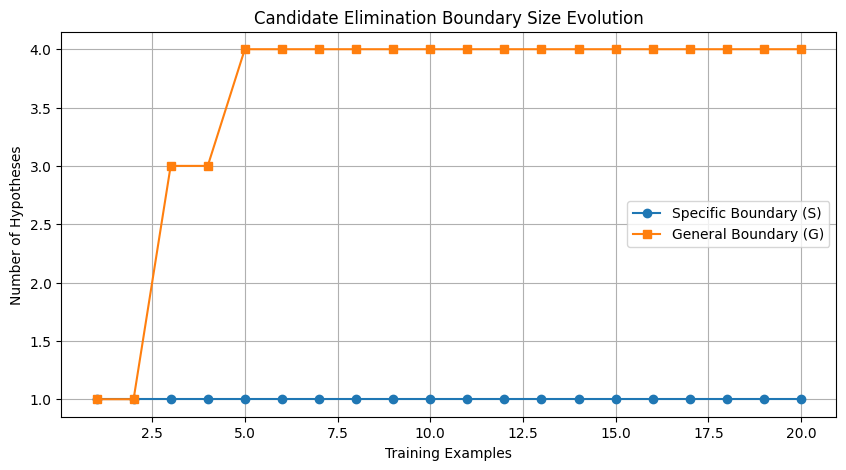

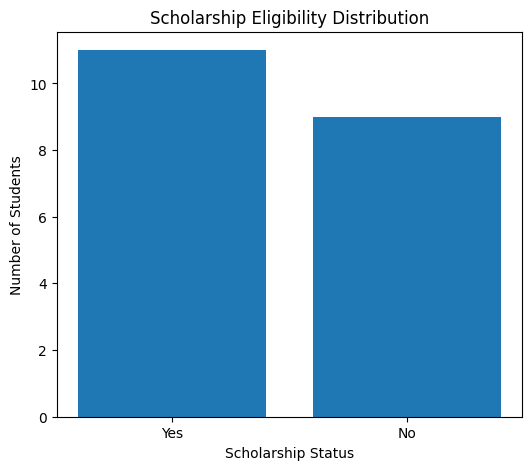

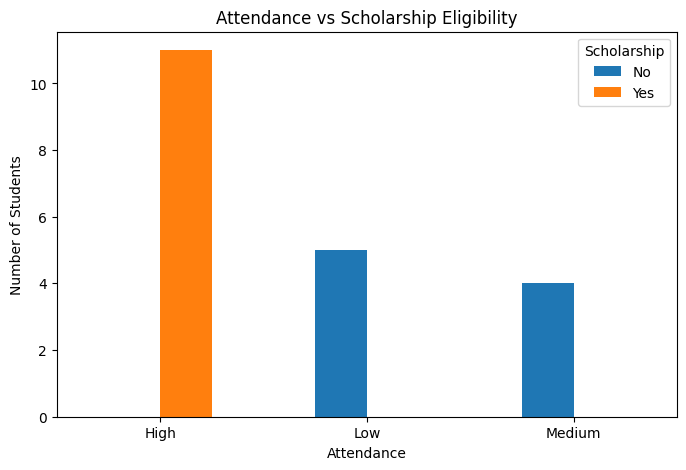

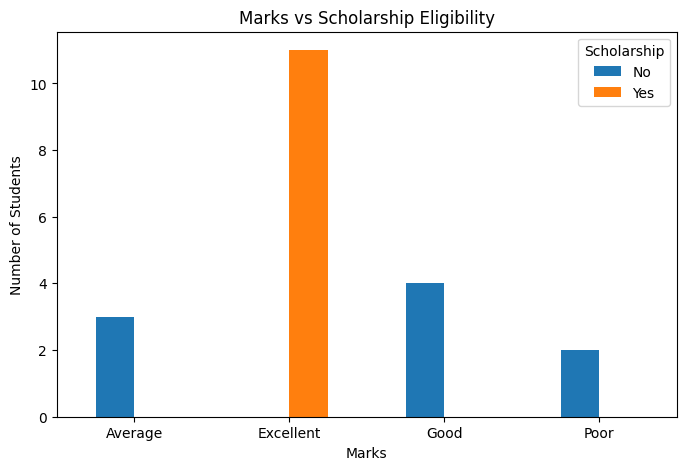

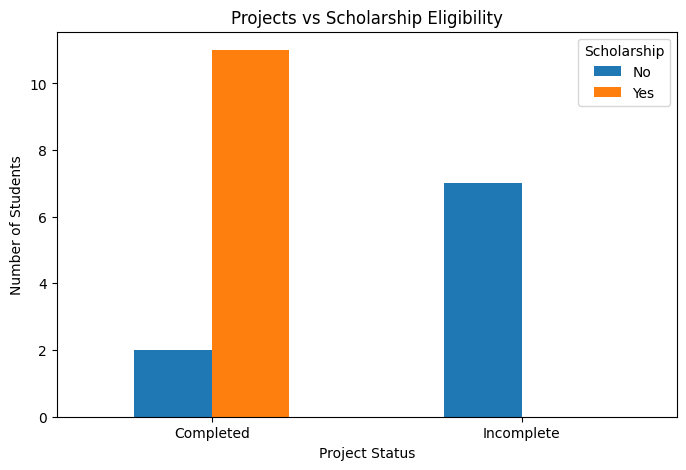

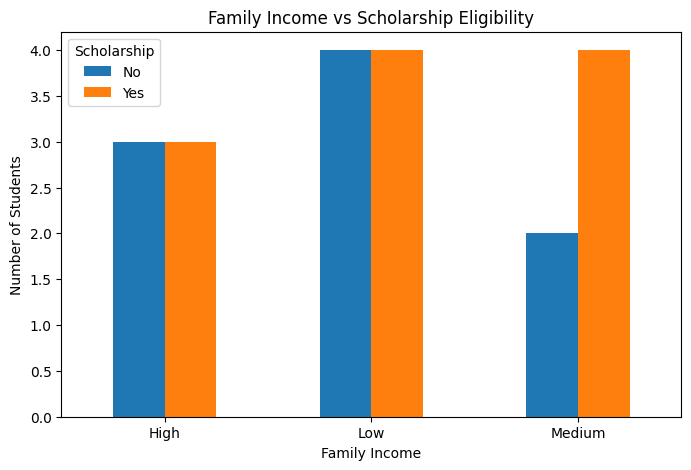

In [1]:
# ============================================================
# CANDIDATE ELIMINATION ALGORITHM
# Dataset: Student Scholarship Eligibility (20 Records)
# With Visualization Graphs
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# 1. DATASET
# ============================================================

attributes = ['Attendance', 'Marks', 'Projects', 'FamilyIncome']

data = [
    ['High',   'Excellent', 'Completed',  'Low',    'Yes'],
    ['High',   'Excellent', 'Completed',  'Medium', 'Yes'],
    ['Low',    'Average',   'Incomplete', 'Low',    'No'],
    ['High',   'Excellent', 'Completed',  'High',   'Yes'],
    ['Medium', 'Good',      'Completed',  'Low',    'No'],
    ['High',   'Excellent', 'Completed',  'Low',    'Yes'],
    ['Low',    'Poor',      'Incomplete', 'High',   'No'],
    ['High',   'Excellent', 'Completed',  'Medium', 'Yes'],
    ['Medium', 'Average',   'Incomplete', 'Medium', 'No'],
    ['High',   'Excellent', 'Completed',  'High',   'Yes'],
    ['Low',    'Good',      'Incomplete', 'Low',    'No'],
    ['High',   'Excellent', 'Completed',  'Low',    'Yes'],
    ['Medium', 'Good',      'Incomplete', 'High',   'No'],
    ['High',   'Excellent', 'Completed',  'Medium', 'Yes'],
    ['Low',    'Average',   'Completed',  'High',   'No'],
    ['High',   'Excellent', 'Completed',  'High',   'Yes'],
    ['Medium', 'Poor',      'Incomplete', 'Low',    'No'],
    ['High',   'Excellent', 'Completed',  'Low',    'Yes'],
    ['Low',    'Good',      'Incomplete', 'Medium', 'No'],
    ['High',   'Excellent', 'Completed',  'Medium', 'Yes']
]

X = [row[:-1] for row in data]
y = [row[-1] for row in data]

n_attributes = len(attributes)


# ============================================================
# 2. CANDIDATE ELIMINATION ALGORITHM
# ============================================================

# Initialize S boundary with most specific hypothesis
S = [['Ø'] * n_attributes]

# Initialize G boundary with most general hypothesis
G = [['?'] * n_attributes]


# Store boundary sizes for graph
s_history = []
g_history = []


# Function to check if hypothesis covers an example
def covers(hypothesis, example):
    for h, x in zip(hypothesis, example):
        if h == '?':
            continue
        elif h == 'Ø':
            return False
        elif h != x:
            return False
    return True


# Function to generalize hypothesis
def generalize(hypothesis, example):

    new_hypothesis = hypothesis.copy()

    for i in range(len(hypothesis)):

        if hypothesis[i] == 'Ø':
            new_hypothesis[i] = example[i]

        elif hypothesis[i] != example[i]:
            new_hypothesis[i] = '?'

    return new_hypothesis


# ============================================================
# 3. RUN CANDIDATE ELIMINATION
# ============================================================

print("=" * 70)
print("CANDIDATE ELIMINATION ALGORITHM")
print("=" * 70)


for index, (example, label) in enumerate(zip(X, y), start=1):

    print(f"\nExample {index}: {example}")
    print(f"Classification: {label}")

    # --------------------------------------------------------
    # POSITIVE EXAMPLE
    # --------------------------------------------------------
    if label == 'Yes':

        new_S = []

        for hypothesis in S:

            if not covers(hypothesis, example):
                generalized = generalize(hypothesis, example)
                new_S.append(generalized)
            else:
                new_S.append(hypothesis)

        S = new_S

        # Remove hypotheses from G that don't cover positive example
        G = [
            hypothesis for hypothesis in G
            if covers(hypothesis, example)
        ]

        print("Positive Example Processed")

    # --------------------------------------------------------
    # NEGATIVE EXAMPLE
    # --------------------------------------------------------
    else:

        new_G = []

        for hypothesis in G:

            # If hypothesis covers negative example,
            # specialize it
            if covers(hypothesis, example):

                for i in range(n_attributes):

                    if hypothesis[i] == '?':

                        # Create specialization using S boundary
                        if S[0][i] != '?' and S[0][i] != 'Ø':

                            new_hypothesis = hypothesis.copy()
                            new_hypothesis[i] = S[0][i]

                            if new_hypothesis not in new_G:
                                new_G.append(new_hypothesis)

            else:
                new_G.append(hypothesis)

        if new_G:
            G = new_G

        print("Negative Example Processed")

    # Store boundary sizes
    s_history.append(len(S))
    g_history.append(len(G))

    print("S Boundary:", S)
    print("G Boundary:", G)


# ============================================================
# 4. DISPLAY FINAL BOUNDARIES
# ============================================================

print("\n" + "=" * 70)
print("FINAL SPECIFIC BOUNDARY (S)")
print("=" * 70)

for hypothesis in S:
    print(hypothesis)


print("\n" + "=" * 70)
print("FINAL GENERAL BOUNDARY (G)")
print("=" * 70)

for hypothesis in G:
    print(hypothesis)


# ============================================================
# 5. GRAPH 1 - S AND G BOUNDARY SIZE
# ============================================================

examples = list(range(1, len(data) + 1))

plt.figure(figsize=(10, 5))

plt.plot(
    examples,
    s_history,
    marker='o',
    label='Specific Boundary (S)'
)

plt.plot(
    examples,
    g_history,
    marker='s',
    label='General Boundary (G)'
)

plt.title("Candidate Elimination Boundary Size Evolution")
plt.xlabel("Training Examples")
plt.ylabel("Number of Hypotheses")

plt.legend()
plt.grid()

plt.show()


# ============================================================
# 6. GRAPH 2 - SCHOLARSHIP DISTRIBUTION
# ============================================================

df = pd.DataFrame(
    data,
    columns=[
        'Attendance',
        'Marks',
        'Projects',
        'FamilyIncome',
        'Scholarship'
    ]
)

scholarship_count = df['Scholarship'].value_counts()

plt.figure(figsize=(6, 5))

plt.bar(
    scholarship_count.index,
    scholarship_count.values
)

plt.title("Scholarship Eligibility Distribution")
plt.xlabel("Scholarship Status")
plt.ylabel("Number of Students")

plt.show()


# ============================================================
# 7. GRAPH 3 - ATTENDANCE VS SCHOLARSHIP
# ============================================================

attendance_graph = pd.crosstab(
    df['Attendance'],
    df['Scholarship']
)

attendance_graph.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title("Attendance vs Scholarship Eligibility")
plt.xlabel("Attendance")
plt.ylabel("Number of Students")

plt.xticks(rotation=0)
plt.legend(title="Scholarship")

plt.show()


# ============================================================
# 8. GRAPH 4 - MARKS VS SCHOLARSHIP
# ============================================================

marks_graph = pd.crosstab(
    df['Marks'],
    df['Scholarship']
)

marks_graph.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title("Marks vs Scholarship Eligibility")
plt.xlabel("Marks")
plt.ylabel("Number of Students")

plt.xticks(rotation=0)
plt.legend(title="Scholarship")

plt.show()


# ============================================================
# 9. GRAPH 5 - PROJECTS VS SCHOLARSHIP
# ============================================================

projects_graph = pd.crosstab(
    df['Projects'],
    df['Scholarship']
)

projects_graph.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title("Projects vs Scholarship Eligibility")
plt.xlabel("Project Status")
plt.ylabel("Number of Students")

plt.xticks(rotation=0)
plt.legend(title="Scholarship")

plt.show()


# ============================================================
# 10. GRAPH 6 - FAMILY INCOME VS SCHOLARSHIP
# ============================================================

income_graph = pd.crosstab(
    df['FamilyIncome'],
    df['Scholarship']
)

income_graph.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title("Family Income vs Scholarship Eligibility")
plt.xlabel("Family Income")
plt.ylabel("Number of Students")

plt.xticks(rotation=0)
plt.legend(title="Scholarship")

plt.show()